### Caso de Crisis Epilépticas
Utilizaremos el dataset real de Breslow (1993), que registra el número de convulsiones en pacientes tras ocho semanas de tratamiento con un fármaco antiepiléptico frente a un placebo

- Respuesta (sumY): Conteo total de convulsiones post-aleatorización
- Predictores: Edad (Age), tratamiento (Trt) y conteo basal previo (Base)



In [2]:
# --- Script: Regresión de Poisson e Inferencia Clínica ---
# Librerías necesarias
if(!require(robust)) install.packages("robust")
library(robust)
data(breslow.dat)

# 1. Especificación del Modelo
# Modelamos el logaritmo de la tasa de convulsiones
fit_poisson <- glm(sumY ~ Base + Age + Trt, 
                   data = breslow.dat, 
                   family = poisson(link = "log"))

# 2. Resumen e Inferencia de Parámetros
summary(fit_poisson)


Call:
glm(formula = sumY ~ Base + Age + Trt, family = poisson(link = "log"), 
    data = breslow.dat)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.9488259  0.1356191  14.370  < 2e-16 ***
Base          0.0226517  0.0005093  44.476  < 2e-16 ***
Age           0.0227401  0.0040240   5.651 1.59e-08 ***
Trtprogabide -0.1527009  0.0478051  -3.194   0.0014 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 2122.73  on 58  degrees of freedom
Residual deviance:  559.44  on 55  degrees of freedom
AIC: 850.71

Number of Fisher Scoring iterations: 5


A. Coeficientes y Razones de Tasa de Incidencia (IRR)
Los coeficientes β 
j
​
  en la salida de R están en escala logarítmica, lo que dificulta su aplicación clínica directa
. Para una interpretación intuitiva, debemos exponenciar los coeficientes para obtener el Incident Rate Ratio (IRR)
: 
```math
IRR=e β j
```
​
 
 Un IRR>1 indica un factor de riesgo (aumenta la frecuencia de eventos), mientras que un IRR<1 indica un factor protector


In [3]:
# Obtención de los IRR y sus intervalos de confianza del 95%
exp(cbind(IRR = coef(fit_poisson), confint(fit_poisson)))

Waiting for profiling to be done...


                   IRR     2.5 %    97.5 %
(Intercept)  7.0204403 5.3756959 9.1481671
Base         1.0229102 1.0218863 1.0239287
Age          1.0230007 1.0149478 1.0310859
Trtprogabide 0.8583864 0.7815616 0.9426684

#### Validación del Modelo y Supuestos
Para que las inferencias sean válidas, el modelo debe cumplir con la equidispersión: la media debe ser aproximadamente igual a la varianza (λ=Var(Y)).
- Detección de Sobredispersión: Ocurre cuando la varianza es mayor a la media. Una regla práctica es observar la razón entre la Devianza Residual y los grados de libertad residuales; si este valor es significativamente mayor a 1, existe sobredispersión.
- Solución Clínica: Si hay sobredispersión, se debe utilizar una distribución Quasi-Poisson, la cual ajusta los errores estándar para evitar falsos positivos

In [6]:
# Evaluación rápida de sobredispersión
cat("Razon de Devianza:", fit_poisson$deviance / fit_poisson$df.residual)

Razon de Devianza: 10.1717

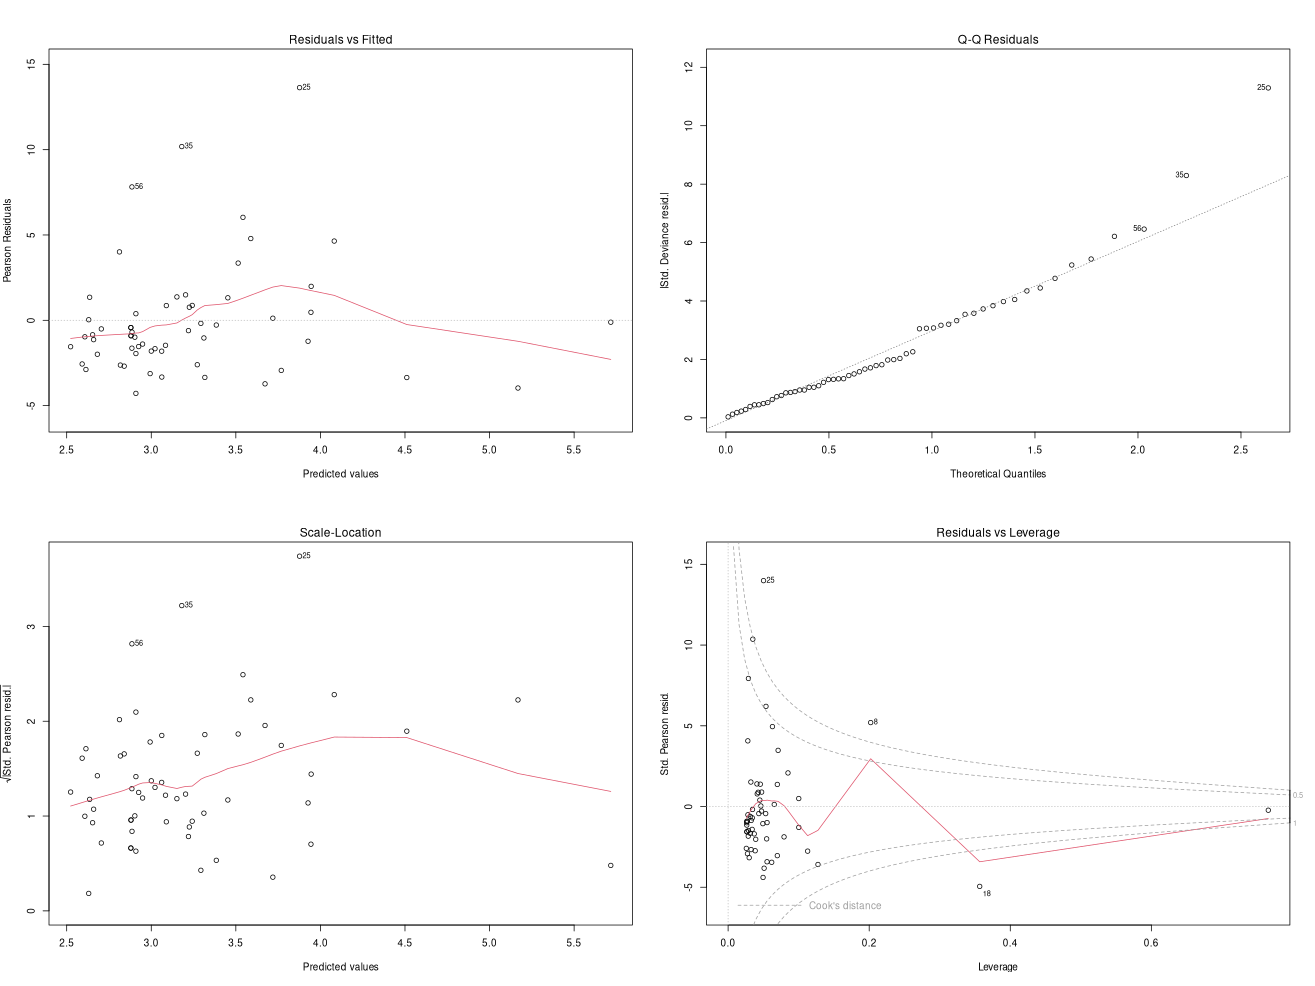

In [4]:
# Gráficos de diagnóstico básicos
par(mfrow = c(2, 2))
plot(fit_poisson) # Genera Residuals vs Fitted, Normal Q-Q, y Cook's Distance


**Conclusión para la Práctica**

En el estudio de breslow.dat, si se detecta que la sobredispersión es alta (por ejemplo, una razón > 10), el efecto real del fármaco (Trt) podría dejar de ser significativo al corregir el modelo. Este es un recordatorio crítico: en la informática médica, el ajuste algorítmico nunca debe preceder a la validación estadística de los supuestos biológicos

5. Detección de Puntos Influyentes y Atípicos